# Calibrating temperature sensors

H.G.K.R. Gunarathna | s17239 | 2023s20003

## Experimental Setup

You are expected to calibrate a thermistor as a temperature sensor in this experiment and in addition, you are expected to evaluate the response time to the device. Use a 1-Wire digital thermometer DS18B20 as the calibration standard.

Key Specifications:
- Temperature Range: -55°C to +125°C (-67°F to +257°F)
- Accuracy: ±0.5°C (from -10°C to +85°C)
- Resolution: Configurable from 9-bit to 12-bit
- Operating Voltage: 3.0V to 5.5V
- Interface: 1-Wire (requires only one digital pin plus ground)
  
Features:
- Unique ID: Each sensor has a factory-burned 64-bit serial code.
- Multi-Drop: You can connect multiple sensors to a single data wire.
- Parasite Power: It can run using power pulled directly from the data line.


## Data Selection

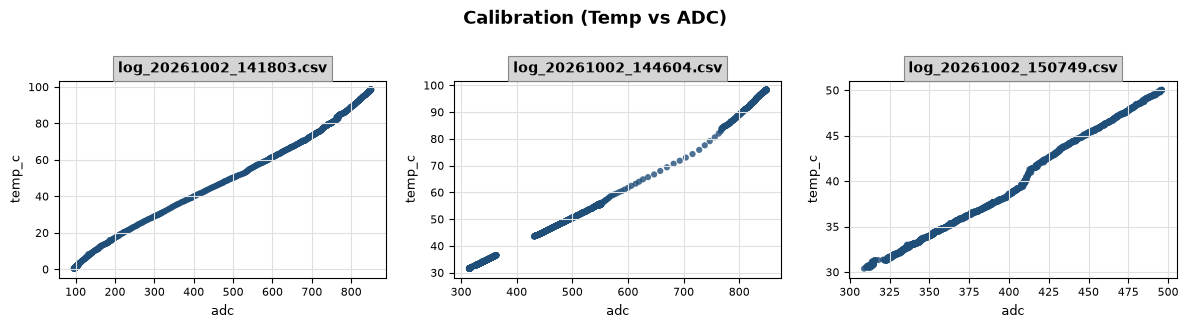

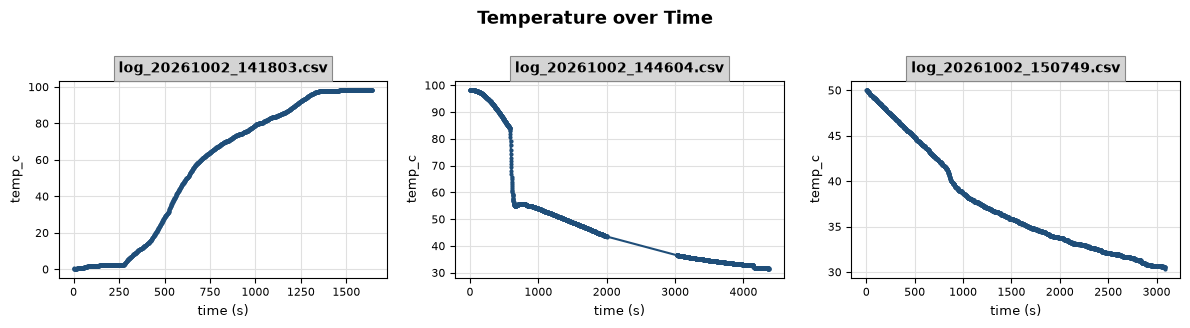

In [1]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.metrics import root_mean_squared_error, max_error, r2_score

# The three valid calibration runs (other runs have a stuck/missing ADC channel)
heating_file = "../data/log_20261002_141803.csv"
cooling_files = [
    "../data/log_20261002_144604.csv",
    "../data/log_20261002_150749.csv",
]
selected_files = [heating_file] + cooling_files

def plot_faceted_grid(file_list, plot_type="calibration", n_cols=3):
    """
    plot_type: 'calibration' (Temp vs ADC) or 'time_series' (Temp vs Time)
    """
    n_files = len(file_list)
    if n_files == 0:
        return

    n_rows = math.ceil(n_files / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, file_path in enumerate(file_list):
        ax = axes_flat[idx]
        file_name = os.path.basename(file_path)
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()

        # --- Grey Banner Title (ggplot style) ---
        ax.set_title(
            file_name, 
            fontsize=10, 
            fontweight='bold',
            pad=6,
            bbox=dict(boxstyle="square,pad=0.35", facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8)
        )

        if plot_type == "calibration":
            # Temp vs ADC
            x = df['adc']
            y = df['temp_c']
            ax.scatter(x, y, color="#1f4e79", s=20, alpha=0.8, edgecolors='none')
            ax.set_xlabel("adc", fontsize=9)
            ax.set_ylabel("temp_c", fontsize=9)

        elif plot_type == "time_series":
            # Temp vs Time
            t_sec = df['time_ms'] / 1000.0
            ax.plot(t_sec, df['temp_c'], color="#1f4e79", marker='.', markersize=4, linestyle='-')
            ax.set_xlabel("time (s)", fontsize=9)
            ax.set_ylabel("temp_c", fontsize=9)

        # Background grid styling
        ax.grid(True, color="#e0e0e0", linestyle="-", linewidth=0.8)
        ax.tick_params(labelsize=8)

    # Hide any unused subplot panels (e.g. if 7 files in a 3x3 grid)
    for j in range(n_files, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    fig.suptitle(
        f"{'Calibration (Temp vs ADC)' if plot_type == 'calibration' else 'Temperature over Time'}",
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()


plot_faceted_grid(selected_files, plot_type="calibration", n_cols=3)
plot_faceted_grid(selected_files, plot_type="time_series", n_cols=3)


## Heating Process

In [2]:
# 1. Load the heating run and prepare clean data arrays
df = pd.read_csv(heating_file)
df.columns = df.columns.str.strip()
missing_rows = df[df[['adc', 'temp_c']].isna().any(axis=1)]
clean_df = df.dropna(subset=['adc', 'temp_c']).copy()
x, y = clean_df['adc'].values, clean_df['temp_c'].values
x_smooth = np.linspace(x.min(), x.max(), 300)

# 2. Fit Degrees 1, 2, 3 for Plotting & Scikit-Learn Metrics
degrees = [1, 2, 3]
colors = ['#d9534f', '#2ca02c', '#1f77b4']
models = {}
fit_results = []

for deg in degrees:
    poly = np.poly1d(np.polyfit(x, y, deg))
    y_pred = poly(x)
    models[deg] = poly
    
    fit_results.append({
        "Degree": f"Deg {deg}",
        "R²": f"{r2_score(y, y_pred):.5f}",
        "RMSE (°C)": f"{root_mean_squared_error(y, y_pred):.3f}",
        "Max Error (°C)": f"{max_error(y, y_pred):.3f}",
        "Residuals": y - y_pred
    })

print("CALIBRATION MODEL ACCURACY:")
print(pd.DataFrame(fit_results).drop(columns=['Residuals']).to_string(index=False))

# 3. Statsmodels Scientific Summary (for the optimal Degree 3 fit)
print("\n" + "=" * 65 + "\nSTATSMODELS DEGREE 3 REPORT:")
ols_deg3 = smf.ols('temp_c ~ adc + I(adc**2) + I(adc**3)', data=clean_df).fit()
print(ols_deg3.summary())

CALIBRATION MODEL ACCURACY:
Degree      R² RMSE (°C) Max Error (°C)
 Deg 1 0.99600     2.326          3.913
 Deg 2 0.99718     1.951          4.146
 Deg 3 0.99991     0.345          1.459

STATSMODELS DEGREE 3 REPORT:
                            OLS Regression Results                            
Dep. Variable:                 temp_c   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.062e+06
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:17:53   Log-Likelihood:                -382.88
No. Observations:                1078   AIC:                             773.8
Df Residuals:                    1074   BIC:                             793.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                  

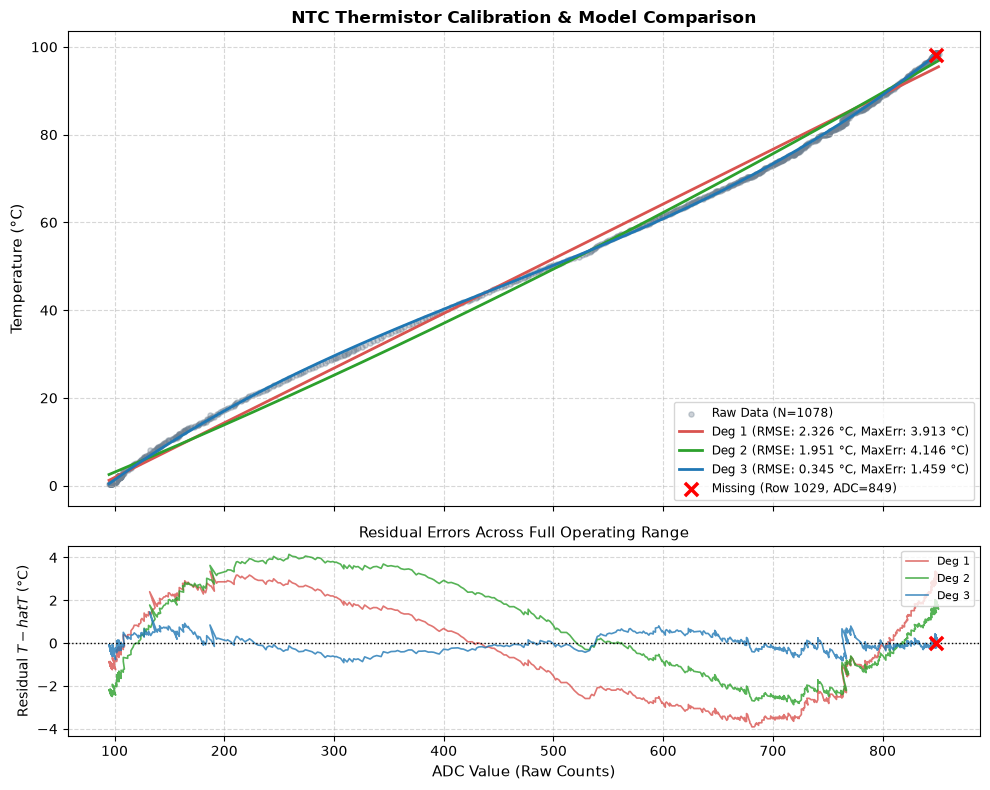

In [3]:
# Create the linked 2-panel figure
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), 
    gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True
)

# --- Top Subplot: Calibration Fits ---
ax1.scatter(x, y, color='slategray', s=14, alpha=0.35, label=f'Raw Data (N={len(x)})')

for deg, color in zip(degrees, colors):
    row_info = next(item for item in fit_results if item["Degree"] == f"Deg {deg}")
    ax1.plot(x_smooth, models[deg](x_smooth), color=color, linewidth=2, 
             label=f"Deg {deg} (RMSE: {row_info['RMSE (°C)']} °C, MaxErr: {row_info['Max Error (°C)']} °C)")

# Mark missing data point(s) with dashed line and 'X'
for _, m_row in missing_rows.iterrows():
    if pd.notna(m_row['adc']):
        adc_val = m_row['adc']
        est_temp = models[3](adc_val)
        ax1.scatter(adc_val, est_temp, color='red', marker='x', s=90, linewidths=2.5, zorder=5, 
                    label=f'Missing (Row {m_row.name}, ADC={int(adc_val)})')
        ax2.scatter(adc_val, 0, color='red', marker='x', s=90, linewidths=2.5, zorder=5)

ax1.set_ylabel("Temperature (°C)", fontsize=11)
ax1.set_title("NTC Thermistor Calibration & Model Comparison", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=8.5)

# --- Bottom Subplot: Residual Distribution ---
for deg, color in zip(degrees, colors):
    res = next(item for item in fit_results if item["Degree"] == f"Deg {deg}")['Residuals']
    ax2.plot(x, res, color=color, linewidth=1.2, alpha=0.8, label=f"Deg {deg}")
ax2.axhline(0, color='black', linestyle=':', linewidth=1)
ax2.set_xlabel("ADC Value (Raw Counts)", fontsize=11)
ax2.set_ylabel("Residual $T - hat{T}$ (°C)", fontsize=10)
ax2.set_title("Residual Errors Across Full Operating Range", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Cooling Process

In [4]:
# 1. Load and tag both cooling data sources
dfs = []
for path in cooling_files:
    temp_df = pd.read_csv(path)
    temp_df.columns = temp_df.columns.str.strip()
    temp_df['source'] = os.path.basename(path)
    dfs.append(temp_df)

cool_df = pd.concat(dfs, ignore_index=True)

# 2. Audit missing data & Outlier Detection
missing_rows_cool = cool_df[cool_df[['adc', 'temp_c']].isna().any(axis=1)]
clean_cool_df = cool_df.dropna(subset=['adc', 'temp_c']).copy()

# Initial cubic fit to identify statistical outliers (|residual| > 2.5 * sigma)
init_poly = np.poly1d(np.polyfit(clean_cool_df['adc'], clean_cool_df['temp_c'], 3))
residuals_init = clean_cool_df['temp_c'] - init_poly(clean_cool_df['adc'])
sigma_threshold = 2.5 * residuals_init.std()

outlier_mask = residuals_init.abs() > sigma_threshold
outliers_cool = clean_cool_df[outlier_mask].copy()
filtered_cool_df = clean_cool_df[~outlier_mask].copy()

print("=" * 65)
print("DATA AUDIT & OUTLIER TREATMENT (COMBINED COOLING):")
print(f"Total Logged Samples  : {len(cool_df)}")
print(f"Missing (NaN)         : {len(missing_rows_cool)}")
print(f"Outliers Flagged      : {len(outliers_cool)} (|res| > {sigma_threshold:.2f} °C)")
print(f"Final Inliers Retained: {len(filtered_cool_df)}")
if len(outliers_cool) > 0:
    print("\nSample Flagged Outliers (first 5):")
    print(outliers_cool[['source', 'adc', 'temp_c']].head().to_string(index=False))
print("=" * 65)

# Fit models ONLY on filtered inliers
x_cool = filtered_cool_df['adc'].values
y_cool = filtered_cool_df['temp_c'].values
x_cool_smooth = np.linspace(x_cool.min(), x_cool.max(), 300)

# 3. Fit Models & Compute Metrics
degrees = [1, 2, 3]
colors = ['#d9534f', '#2ca02c', '#1f77b4']
cool_models = {}
cool_results = []

for deg in degrees:
    poly = np.poly1d(np.polyfit(x_cool, y_cool, deg))
    y_pred = poly(x_cool)
    cool_models[deg] = poly
    
    cool_results.append({
        "Degree": f"Deg {deg}",
        "R²": f"{r2_score(y_cool, y_pred):.5f}",
        "RMSE (°C)": f"{root_mean_squared_error(y_cool, y_pred):.3f}",
        "Max Error (°C)": f"{max_error(y_cool, y_pred):.3f}",
        "Residuals": y_cool - y_pred
    })

print("\nCOOLING CALIBRATION METRICS:")
print(pd.DataFrame(cool_results).drop(columns=['Residuals']).to_string(index=False))

# 4. Statsmodels cubic fit for cooling
print("\n" + "=" * 65 + "\nSTATSMODELS DEGREE 3 REPORT (COOLING):")
ols_cool = smf.ols('temp_c ~ adc + I(adc**2) + I(adc**3)', data=clean_cool_df).fit()
print(ols_cool.summary())

DATA AUDIT & OUTLIER TREATMENT (COMBINED COOLING):
Total Logged Samples  : 4252
Missing (NaN)         : 2
Outliers Flagged      : 9 (|res| > 1.38 °C)
Final Inliers Retained: 4241

Sample Flagged Outliers (first 5):
                 source  adc  temp_c
log_20261002_144604.csv  763   81.94
log_20261002_144604.csv  756   80.56
log_20261002_144604.csv  747   79.12
log_20261002_144604.csv  738   77.56
log_20261002_144604.csv  728   75.87

COOLING CALIBRATION METRICS:
Degree      R² RMSE (°C) Max Error (°C)
 Deg 1 0.99266     1.461          4.004
 Deg 2 0.99883     0.584          2.373
 Deg 3 0.99898     0.545          1.445

STATSMODELS DEGREE 3 REPORT (COOLING):
                            OLS Regression Results                            
Dep. Variable:                 temp_c   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.353e+06
Date:            

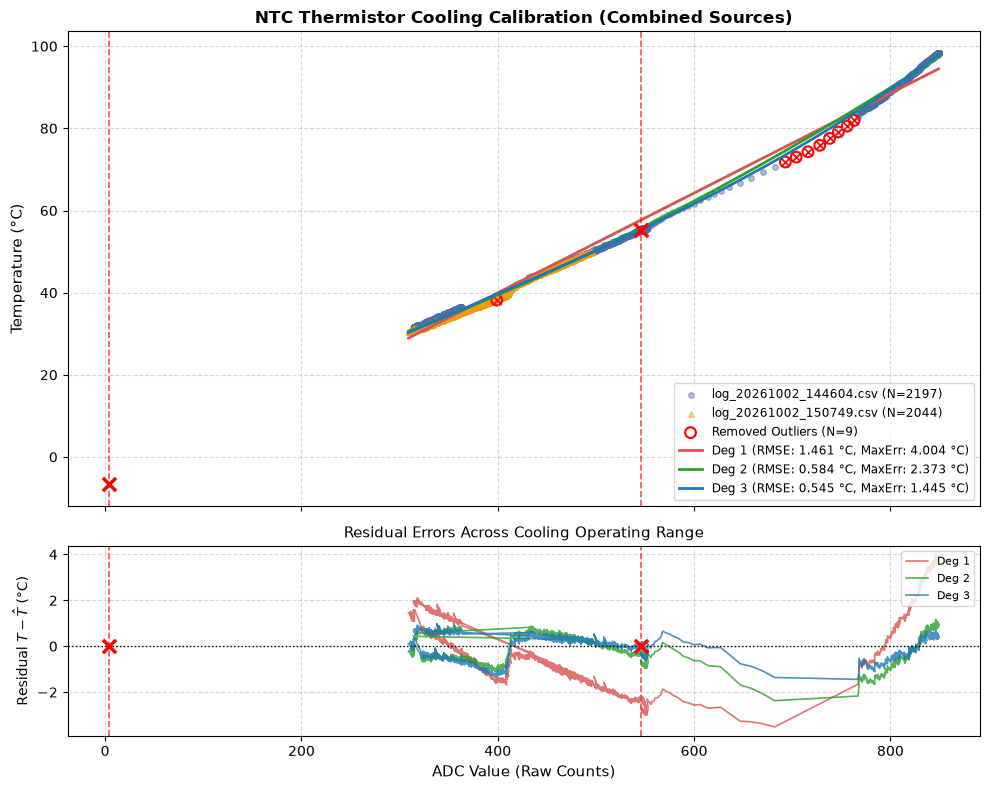

In [5]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), 
    gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True
)

# --- Top Subplot: Scatter inliers by source + Highlight outliers ---
source_markers = {'log_20261002_144604.csv': ('#4a6fa5', 'o'), 
                  'log_20261002_150749.csv': ('#f39c12', '^')}

# 1. Plot filtered inliers
for fname, (color, marker) in source_markers.items():
    subset = filtered_cool_df[filtered_cool_df['source'] == fname]
    ax1.scatter(subset['adc'], subset['temp_c'], color=color, marker=marker, 
                s=16, alpha=0.45, label=f'{fname} (N={len(subset)})')

# 2. Mark removed outliers with red hollow circles and an 'X'
if len(outliers_cool) > 0:
    ax1.scatter(outliers_cool['adc'], outliers_cool['temp_c'], 
                facecolors='none', edgecolors='red', marker='o', s=60, linewidths=1.5,
                label=f'Removed Outliers (N={len(outliers_cool)})')
    ax1.scatter(outliers_cool['adc'], outliers_cool['temp_c'], 
                color='red', marker='x', s=35, linewidths=1.2)

# Overlay polynomial model curves
for deg, color in zip(degrees, colors):
    row_info = next(item for item in cool_results if item["Degree"] == f"Deg {deg}")
    ax1.plot(
        x_cool_smooth, cool_models[deg](x_cool_smooth), color=color, linewidth=2,
        label=f"Deg {deg} (RMSE: {row_info['RMSE (°C)']} °C, MaxErr: {row_info['Max Error (°C)']} °C)"
    )

# Mark missing data (if any exist)
for _, m_row in missing_rows_cool.iterrows():
    if pd.notna(m_row['adc']):
        ax1.axvline(m_row['adc'], color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax1.scatter(m_row['adc'], cool_models[3](m_row['adc']), color='red', marker='x', s=90, linewidths=2.5, zorder=5)
        ax2.axvline(m_row['adc'], color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax2.scatter(m_row['adc'], 0, color='red', marker='x', s=90, linewidths=2.5, zorder=5)

ax1.set_ylabel("Temperature (°C)", fontsize=11)
ax1.set_title("NTC Thermistor Cooling Calibration (Combined Sources)", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=8.5)

# --- Bottom Subplot: Residual Distribution ---
for deg, color in zip(degrees, colors):
    res = next(item for item in cool_results if item["Degree"] == f"Deg {deg}")['Residuals']
    ax2.plot(x_cool, res, color=color, linewidth=1.2, alpha=0.8, label=f"Deg {deg}")

ax2.axhline(0, color='black', linestyle=':', linewidth=1)
ax2.set_xlabel("ADC Value (Raw Counts)", fontsize=11)
ax2.set_ylabel("Residual $T - \\hat{T}$ (°C)", fontsize=10)
ax2.set_title("Residual Errors Across Cooling Operating Range", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Heating vs. Cooling Hysteresis

THERMAL HYSTERESIS CHARACTERIZATION:
Overlap Range            : ADC 309 to 849
Maximum Hysteresis (|ΔT|) : 1.163 °C
Mean Hysteresis (|ΔT|)    : 0.608 °C


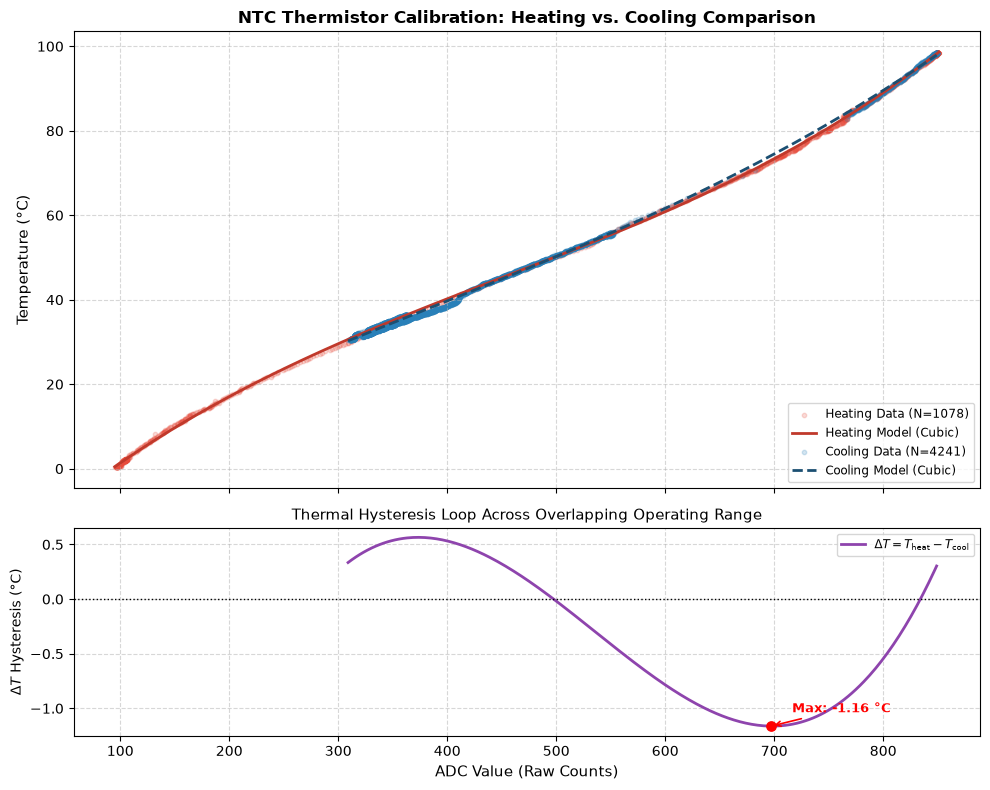

In [6]:
# 1. Determine the overlapping ADC range for both processes
adc_min = max(x.min(), x_cool.min())
adc_max = min(x.max(), x_cool.max())
adc_common = np.linspace(adc_min, adc_max, 300)

# 2. Evaluate both cubic models and calculate hysteresis
t_heat_eval = models[3](adc_common)
t_cool_eval = cool_models[3](adc_common)
hysteresis = t_heat_eval - t_cool_eval

max_hyst = np.max(np.abs(hysteresis))
avg_hyst = np.mean(np.abs(hysteresis))

print("=" * 60)
print("THERMAL HYSTERESIS CHARACTERIZATION:")
print(f"Overlap Range            : ADC {adc_min:.0f} to {adc_max:.0f}")
print(f"Maximum Hysteresis (|ΔT|) : {max_hyst:.3f} °C")
print(f"Mean Hysteresis (|ΔT|)    : {avg_hyst:.3f} °C")
print("=" * 60)

# 3. Two-Panel Plot: Overlay & Hysteresis Deviation
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), 
    gridspec_kw={'height_ratios': [2.2, 1]}, sharex=True
)

# --- Top Plot: Direct Overlay of Heating vs Cooling ---
ax1.scatter(x, y, color='#e74c3c', s=10, alpha=0.2, label=f'Heating Data (N={len(x)})')
ax1.plot(x_smooth, models[3](x_smooth), color='#c0392b', linewidth=2, label='Heating Model (Cubic)')

ax1.scatter(x_cool, y_cool, color='#2980b9', s=10, alpha=0.2, label=f'Cooling Data (N={len(x_cool)})')
ax1.plot(x_cool_smooth, cool_models[3](x_cool_smooth), color='#1b4f72', linewidth=2, linestyle='--', label='Cooling Model (Cubic)')

ax1.set_ylabel("Temperature (°C)", fontsize=11)
ax1.set_title("NTC Thermistor Calibration: Heating vs. Cooling Comparison", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=8.5)

# --- Bottom Plot: Thermal Hysteresis (ΔT = T_heat - T_cool) ---
ax2.plot(adc_common, hysteresis, color='#8e44ad', linewidth=2, 
         label=r'$\Delta T = T_{\mathrm{heat}} - T_{\mathrm{cool}}$')
ax2.axhline(0, color='black', linestyle=':', linewidth=1)

# Annotate maximum hysteresis point
idx_max = np.argmax(np.abs(hysteresis))
ax2.scatter(adc_common[idx_max], hysteresis[idx_max], color='red', s=45, zorder=5)
ax2.annotate(
    f'Max: {hysteresis[idx_max]:.2f} °C',
    (adc_common[idx_max], hysteresis[idx_max]),
    xytext=(15, 10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
    fontweight='bold', color='red', fontsize=9
)

ax2.set_xlabel("ADC Value (Raw Counts)", fontsize=11)
ax2.set_ylabel(r"$\Delta T$ Hysteresis (°C)", fontsize=10)
ax2.set_title("Thermal Hysteresis Loop Across Overlapping Operating Range", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()

The maximum temperature discrepancy between the heating and cooling cycles was determined to be $1.16\,^\circ\text{C}$ ($1.16\%\text{ FS}$), with a mean deviation of $0.61\,^\circ\text{C}$. This is primarily attributed to dynamic thermal lag between the reference thermometer and the thermistor probe during transient temperature changes, rather than physical sensor hysteresis. Because the mean deviation is within the experimental uncertainty of the reference thermometer ($\pm 1\,^\circ\text{C}$), a single cubic calibration model is sufficient to characterize the sensor across both operating directions.

### Root Cause 1: Thermal Time Constant Lag ($\tau$)
This is the main cause of the $\approx 1^\circ\text{C}$ shift:
* The NTC bead and the reference probe have different thermal masses and encapsulation casings.
* Therefore, they have different thermal time constants ($\tau = R_{\text{thermal}} \times C_{\text{thermal}}$).
* Because the water was heating up ($+\frac{dT}{dt}$) and cooling down ($-\frac{dT}{dt}$), one sensor was always lagging slightly behind the other. This dynamic delay shows up in the data looking like hysteresis.

### Root Cause 2: Mathematical Artifact (Subtracting Polynomials)
The bottom curve is a clean, smooth wave crossing zero around $\text{ADC} \approx 500$:

$$\Delta T = P_{\text{heat}}(x) - P_{\text{cool}}(x) = (a_3 - b_3)x^3 + (a_2 - b_2)x^2 + (a_1 - b_1)x + (a_0 - b_0)$$

Subtracting two cubic polynomials mathematically guarantees a cubic wave with peaks and zero-crossings. Part of the wave is just how the polynomial smoothed through the stitched cooling data.

### Root Cause 3: Water Bath Convection
Unless the water was rapidly and continuously stirred with a magnetic stirrer, warm water rises and creates thermal gradients between where the reference thermometer and the NTC probe were placed.

## Global Calibration & 95% Prediction Band

FINAL CALIBRATED NTC MODEL EQUATION:
T(ADC) = (1.8686e-07)·ADC³ + (-2.4948e-04)·ADC² + (2.1343e-01)·ADC + (-17.5580)  ±  1.06 °C (95% CI)

STATSMODELS DEGREE 3 REPORT (COOLING):
                            OLS Regression Results                            
Dep. Variable:                 temp_c   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.215e+06
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:18:18   Log-Likelihood:                -4268.2
No. Observations:                5319   AIC:                             8544.
Df Residuals:                    5315   BIC:                             8571.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std er

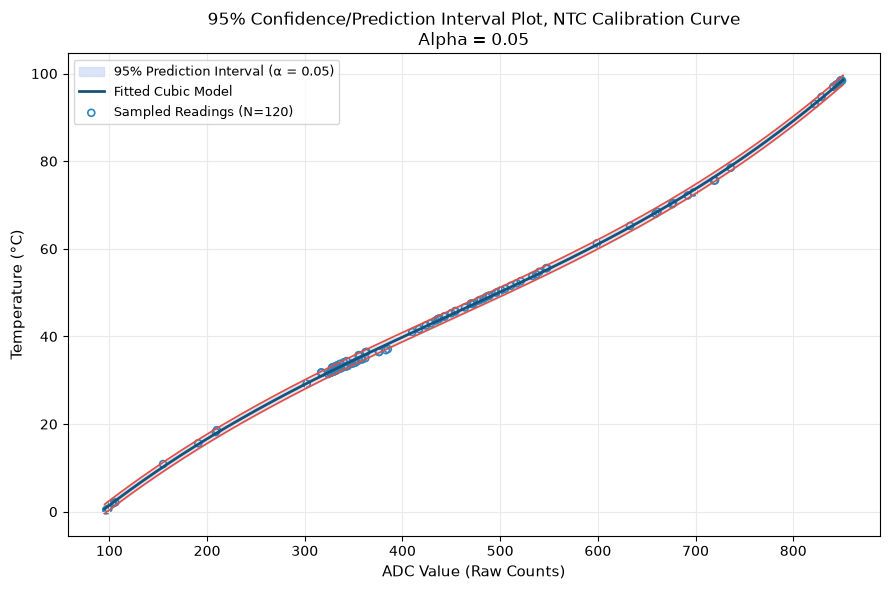

In [7]:
# 1. Combine heating and cleaned cooling data for a universal sensor calibration
comb_df = pd.concat([
    pd.DataFrame({'adc': x, 'temp_c': y}),
    pd.DataFrame({'adc': x_cool, 'temp_c': y_cool})
], ignore_index=True)

# 2. Fit final global cubic model
final_model = smf.ols('temp_c ~ adc + I(adc**2) + I(adc**3)', data=comb_df).fit()

# Extract coefficients
c0 = final_model.params['Intercept']
c1 = final_model.params['adc']
c2 = final_model.params['I(adc ** 2)']
c3 = final_model.params['I(adc ** 3)']

# 3. Calculate 95% Prediction Interval (Alpha = 0.05) across full range
adc_eval = pd.DataFrame({'adc': np.linspace(comb_df['adc'].min(), comb_df['adc'].max(), 400)})
pred_res = final_model.get_prediction(adc_eval).summary_frame(alpha=0.05)

t_fit = pred_res['mean']
lower_bound = pred_res['obs_ci_lower']   # Lower 95% prediction limit (red line)
upper_bound = pred_res['obs_ci_upper']   # Upper 95% prediction limit (red line)
margin = (upper_bound - lower_bound) / 2.0
avg_uncertainty = margin.mean()

# Print Final Equation for Report
print("=" * 65)
print("FINAL CALIBRATED NTC MODEL EQUATION:")
print(f"T(ADC) = ({c3:.4e})·ADC³ + ({c2:.4e})·ADC² + ({c1:.4e})·ADC + ({c0:.4f})  ±  {avg_uncertainty:.2f} °C (95% CI)")
print("=" * 65)

# Statsmodels cubic fit for cooling
print("\n" + "=" * 65 + "\nSTATSMODELS DEGREE 3 REPORT (COOLING):")
print(final_model.summary())


# 4. Plot matching the reference image style
fig, ax = plt.subplots(figsize=(9, 6))

# Shaded 95% region
ax.fill_between(adc_eval['adc'], lower_bound, upper_bound, 
                color='#c8d8f8', alpha=0.65, label='95% Prediction Interval (α = 0.05)')

# Red upper & lower boundary curves
ax.plot(adc_eval['adc'], upper_bound, color='#e74c3c', linewidth=1.2)
ax.plot(adc_eval['adc'], lower_bound, color='#e74c3c', linewidth=1.2)

# Central fitted model curve
ax.plot(adc_eval['adc'], t_fit, color='#1a5276', linewidth=2, label='Fitted Cubic Model')

# Sampled measured data points (open circles like MATLAB reference)
sample_pts = comb_df.sample(n=min(120, len(comb_df)), random_state=42)
ax.scatter(sample_pts['adc'], sample_pts['temp_c'], 
           facecolors='none', edgecolors='#2e86c1', s=25, linewidths=1.2, 
           label=f'Sampled Readings (N={len(sample_pts)})')

ax.set_title("95% Confidence/Prediction Interval Plot, NTC Calibration Curve\nAlpha = 0.05", fontsize=12)
ax.set_xlabel("ADC Value (Raw Counts)", fontsize=11)
ax.set_ylabel("Temperature (°C)", fontsize=11)
ax.grid(True, linestyle='-', color='#eaeaea')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


## Theoretical Model: NTC β-Model

#### Circuit Analysis & Ratiometric ADC Conversion
The data acquisition circuit consists of an NTC thermistor ($R_{\text{NTC}}$) in series with a fixed precision resistor ($R_{\text{fixed}}$) forming a voltage divider supplied by $V_{\text{cc}}$. 

The output voltage across the fixed resistor is given by:
$$V_{\text{out}} = V_{\text{cc}} \cdot \frac{R_{\text{fixed}}}{R_{\text{NTC}} + R_{\text{fixed}}}$$

An $n$-bit Analog-to-Digital Converter (ADC) quantizes $V_{\text{out}}$ with reference voltage $V_{\text{ref}}$:
$$\text{ADC} = \left(\frac{V_{\text{out}}}{V_{\text{ref}}}\right) \cdot \text{ADC}_{\max}$$

Because the microcontroller's ADC reference is tied directly to the supply rail ($V_{\text{ref}} = V_{\text{cc}}$), the measurement is **ratiometric**, making it completely independent of power supply drift:
$$\text{ADC} = \text{ADC}_{\max} \cdot \frac{R_{\text{fixed}}}{R_{\text{NTC}} + R_{\text{fixed}}}$$

#### Isolating the Resistance Ratio ($r$)
To find the thermistor's resistance from raw counts, we rearrange the equation algebraically:

$$\text{ADC} \cdot (R_{\text{NTC}} + R_{\text{fixed}}) = \text{ADC}_{\max} \cdot R_{\text{fixed}}$$

$$\text{ADC} \cdot R_{\text{NTC}} + \text{ADC} \cdot R_{\text{fixed}} = \text{ADC}_{\max} \cdot R_{\text{fixed}}$$

$$\text{ADC} \cdot R_{\text{NTC}} = (\text{ADC}_{\max} - \text{ADC}) \cdot R_{\text{fixed}}$$

Dividing both sides by $\text{ADC} \cdot R_{\text{fixed}}$ defines the dimensionless **resistance ratio** $r$:
$$r \equiv \frac{R_{\text{NTC}}}{R_{\text{fixed}}} = \frac{\text{ADC}_{\max} - \text{ADC}}{\text{ADC}}$$

#### Solid-State Physics Model (Arrhenius Relation)
An NTC thermistor is composed of sintered semiconductor metal oxides. Its electrical conduction is governed by thermal excitation of charge carriers across the bandgap energy $E_g$, described by the Arrhenius relation:
$$R(T) = R_0 \cdot \exp\left[\beta \left(\frac{1}{T} - \frac{1}{T_0}\right)\right]$$

Where:
* $T$ is the absolute temperature in Kelvin ($\text{K}$).
* $T_0$ is the standard reference temperature ($298.15\text{ K} = 25^\circ\text{C}$).
* $R_0 = R(T_0)$ is the nominal resistance at $25^\circ\text{C}$ (e.g., $10\text{ k}\Omega$).
* $\beta = \frac{E_g}{2 k_B}$ is the material characteristic temperature constant ($\text{K}$).

#### Coupling Circuit Theory to Semiconductor Physics
Dividing both sides of the Arrhenius equation by $R_{\text{fixed}}$:
$$\frac{R(T)}{R_{\text{fixed}}} = \left(\frac{R_0}{R_{\text{fixed}}}\right) \cdot \exp\left[\beta \left(\frac{1}{T} - \frac{1}{T_0}\right)\right]$$

Substituting the measured circuit ratio $r = \frac{R(T)}{R_{\text{fixed}}}$ and defining the reference ratio $r_0 \equiv \frac{R_0}{R_{\text{fixed}}}$:
$$r = r_0 \cdot \exp\left[\beta \left(\frac{1}{T} - \frac{1}{T_0}\right)\right]$$

Now take the natural logarithm ($\ln$) of both sides:
$$\ln(r) = \ln(r_0) + \beta \left(\frac{1}{T} - \frac{1}{T_0}\right)$$

Distribute $\beta$ and group terms:
$$\ln(r) = \beta \cdot \left(\frac{1}{T}\right) + \left[\ln(r_0) - \frac{\beta}{T_0}\right]$$

This is strictly in standard linear equation form:
$$\mathbf{y = m \cdot x + c}$$

Where:
* Independent variable: $x = \frac{1}{T}$ ($\text{K}^{-1}$)
* Dependent variable: $y = \ln(r) = \ln\left(\frac{1023 - \text{ADC}}{\text{ADC}}\right)$
* **Slope:** $m = \beta$ (Extracts the physical material constant directly)
* **Intercept:** $c = \ln\left(\frac{R_0}{R_{\text{fixed}}}\right) - \frac{\beta}{T_0}$

#### Inverting for Practical Sensor Calibration ($T$ from ADC)
In a real data acquisition application, the microcontroller measures raw $\text{ADC}$ counts and must compute temperature $T$. 

We rearrange the linear relationship to solve directly for $T$:

$$\ln(r) - c = \beta \cdot \left(\frac{1}{T}\right)$$

$$\frac{1}{T} = \frac{1}{\beta} \cdot \ln(r) - \frac{c}{\beta}$$

Letting calibration coefficients $A = \frac{1}{\beta}$ and $B = -\frac{c}{\beta} = \frac{1}{T_0} - \frac{1}{\beta}\ln\left(\frac{R_0}{R_{\text{fixed}}}\right)$:

$$\frac{1}{T_{\text{Kelvin}}} = A \cdot \ln\left(\frac{1023 - \text{ADC}}{\text{ADC}}\right) + B$$

Finally, taking the reciprocal and converting to Celsius gives the **complete calibration equation**:
$$T_{\text{Celsius}} = \left[\frac{1}{A \cdot \ln\left(\frac{1023 - \text{ADC}}{\text{ADC}}\right) + B}\right] - 273.15$$

#### Summary

| Step | Expression | Physical / Engineering Meaning |
| :--- | :--- | :--- |
| **Voltage Divider** | $r = \frac{1023 - \text{ADC}}{\text{ADC}}$ | Ratiometric cancellation of $V_{\text{cc}}$ noise; isolates resistance ratio. |
| **Semiconductor Physics** | $R(T) \propto e^{\beta / T}$ | Arrhenius charge carrier excitation across energy bandgap $E_g$. |
| **Linear Model ($y=mx+c$)** | $\ln(r) = \beta \cdot \frac{1}{T} + c$ | Slope directly yields $\beta_{\text{exp}} = 3965.3\text{ K}$. |
| **Runtime Sensor Formula** | $T = \frac{1}{A \ln(r) + B} - 273.15$ | Direct calibration algorithm programmed into the data logger firmware. |

## β-Model Validation

PHYSICAL NTC BETA-MODEL (LINEARIZED):
Extracted β (Beta constant) : 3965.3 K
Linear Fit Quality (R²)     : 0.99932
Calibration RMSE            : 0.598 °C


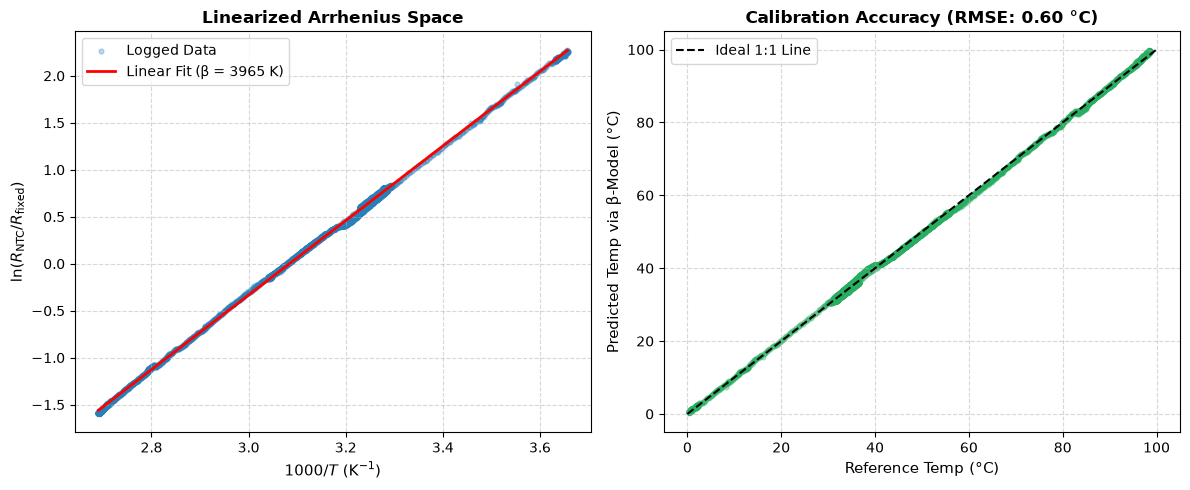

In [8]:
# 1. Prepare data in Kelvin
# (Using combined clean data from heating/cooling)
adc_vals = comb_df['adc'].values
temp_k = comb_df['temp_c'].values + 273.15  # Convert to Kelvin

# 2. Physics Transform: Resistance ratio logarithm vs Inverse Absolute Temperature
# r = (1023 - ADC) / ADC
# Clip ADC slightly away from 0/1023 to prevent log(0) / division by zero
adc_clipped = np.clip(adc_vals, 1, 1022)
ln_r = np.log((1023.0 - adc_clipped) / adc_clipped)
inv_T = 1.0 / temp_k

# 3. Fit a simple STRAIGHT LINE (Degree 1: y = beta * x + c)
# ln(r) = beta * (1/T) + const  ===>  1/T = (1/beta) * ln(r) + const2
slope, intercept = np.polyfit(inv_T, ln_r, 1)
beta_value = slope

# Calibration form: Predict Temperature from ln(r)
slope_cal, intercept_cal = np.polyfit(ln_r, inv_T, 1)
t_pred_k = 1.0 / (slope_cal * ln_r + intercept_cal)
t_pred_c = t_pred_k - 273.15
actual_c = comb_df['temp_c'].values

rmse_beta = root_mean_squared_error(actual_c, t_pred_c)
r2_beta = r2_score(actual_c, t_pred_c)

print("=" * 60)
print(f"PHYSICAL NTC BETA-MODEL (LINEARIZED):")
print(f"Extracted β (Beta constant) : {beta_value:.1f} K")
print(f"Linear Fit Quality (R²)     : {r2_beta:.5f}")
print(f"Calibration RMSE            : {rmse_beta:.3f} °C")
print("=" * 60)

# 4. Plot the linearized physical model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Linearized Physics Space [ln(R) vs 1/T]
ax1.scatter(inv_T * 1000, ln_r, color='#2980b9', s=12, alpha=0.3, label='Logged Data')
inv_T_line = np.linspace(inv_T.min(), inv_T.max(), 100)
ax1.plot(inv_T_line * 1000, slope * inv_T_line + intercept, color='red', linewidth=2, 
         label=f'Linear Fit (β = {beta_value:.0f} K)')
ax1.set_xlabel(r'$1000 / T$ ($\mathrm{K}^{-1}$)', fontsize=11)
ax1.set_ylabel(r'$\ln(R_{\mathrm{NTC}} / R_{\mathrm{fixed}})$', fontsize=11)
ax1.set_title("Linearized Arrhenius Space", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Plot 2: Resulting Temperature Prediction
ax2.scatter(actual_c, t_pred_c, color='#27ae60', s=12, alpha=0.3)
ax2.plot([0, 100], [0, 100], 'k--', label='Ideal 1:1 Line')
ax2.set_xlabel("Reference Temp (°C)", fontsize=11)
ax2.set_ylabel("Predicted Temp via β-Model (°C)", fontsize=11)
ax2.set_title(f"Calibration Accuracy (RMSE: {rmse_beta:.2f} °C)", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

## Conclusion

| Model | Parameters | RMSE (°C) | Notes |
| :--- | :---: | :---: | :--- |
| Global cubic polynomial | 4 | 0.54 | Empirical; ±1.06 °C (95% prediction interval) |
| NTC β-model | 2 ($\beta = 3965\text{ K}$, $r_0$) | 0.60 | Physically based; $R^2 = 0.9993$ |



Both models calibrate the thermistor to within the $\pm 1\,^\circ\text{C}$ uncertainty of the DS18B20 reference, and their RMSE differs by only $0.06\,^\circ\text{C}$. The cubic polynomial is marginally more accurate over the measured range (0°C to 98°C) because its extra parameters absorb small deviations from ideal Arrhenius behaviour. The β-model is almost as accurate with half the parameters, it extrapolates sensibly outside the calibrated range, and it yields a physically meaningful constant ($\beta$).

**Recommendation:** use the β-model as the primary calibration, since it is simpler, physically justified and sufficiently accurate. Keep the cubic polynomial as an empirical alternative when the lowest error is needed strictly within the calibrated range. The heating/cooling hysteresis ($\approx 0.6\,^\circ\text{C}$ mean) is below the reference uncertainty, so a single combined calibration is valid for both directions.


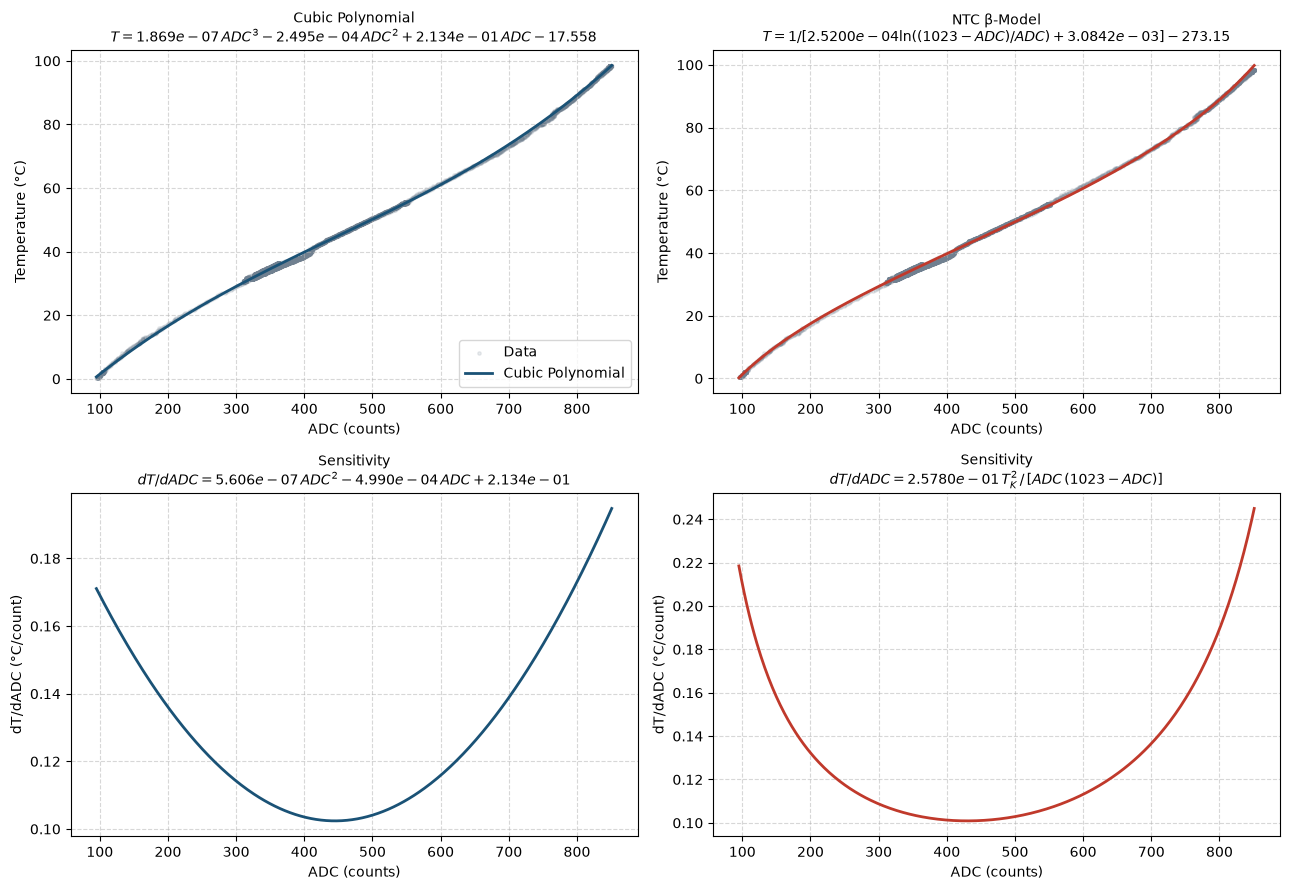

Cubic   dT/dADC: min 0.102, max 0.195 °C/count
β-Model dT/dADC: min 0.101, max 0.245 °C/count


In [9]:
# Model curves and first derivatives (sensitivity dT/dADC)
a = np.linspace(comb_df['adc'].min(), comb_df['adc'].max(), 400)
A, B = slope_cal, intercept_cal

T_poly = c3*a**3 + c2*a**2 + c1*a + c0
S_poly = 3*c3*a**2 + 2*c2*a + c1

T_beta_K = 1.0 / (A*np.log((1023 - a) / a) + B)
T_beta = T_beta_K - 273.15
S_beta = A * 1023 / (a * (1023 - a)) * T_beta_K**2   # dT/dADC of T = 1/(A ln r + B) - 273.15

eq_poly = rf"$T = {c3:.3e}\,ADC^3 {c2:+.3e}\,ADC^2 {c1:+.3e}\,ADC {c0:+.3f}$"
eq_beta = rf"$T = 1/[{A:.4e}\ln((1023-ADC)/ADC) + {B:.4e}] - 273.15$"
d_poly = rf"$dT/dADC = {3*c3:.3e}\,ADC^2 {2*c2:+.3e}\,ADC {c1:+.3e}$"
d_beta = rf"$dT/dADC = {A*1023:.4e}\,T_K^2\,/\,[ADC\,(1023-ADC)]$"

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, (name, T, S, eq, d, color) in enumerate([
        ("Cubic Polynomial", T_poly, S_poly, eq_poly, d_poly, '#1a5276'),
        ("NTC β-Model", T_beta, S_beta, eq_beta, d_beta, '#c0392b')]):
    axes[0, col].scatter(comb_df['adc'], comb_df['temp_c'], s=6, alpha=0.15, color='slategray', label='Data')
    axes[0, col].plot(a, T, color=color, linewidth=2, label=name)
    axes[0, col].set_title(f"{name}\n{eq}", fontsize=10)
    axes[0, col].set_xlabel("ADC (counts)"); axes[0, col].set_ylabel("Temperature (°C)")
    axes[1, col].plot(a, S, color=color, linewidth=2)
    axes[1, col].set_title(f"Sensitivity\n{d}", fontsize=10)
    axes[1, col].set_xlabel("ADC (counts)"); axes[1, col].set_ylabel("dT/dADC (°C/count)")
    for r in (0, 1):
        axes[r, col].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Cubic   dT/dADC: min {S_poly.min():.3f}, max {S_poly.max():.3f} °C/count")
print(f"β-Model dT/dADC: min {S_beta.min():.3f}, max {S_beta.max():.3f} °C/count")


## Response Time Log

Loads the response-test log and plots the DS18B20 temperature and the thermistor ADC against time.

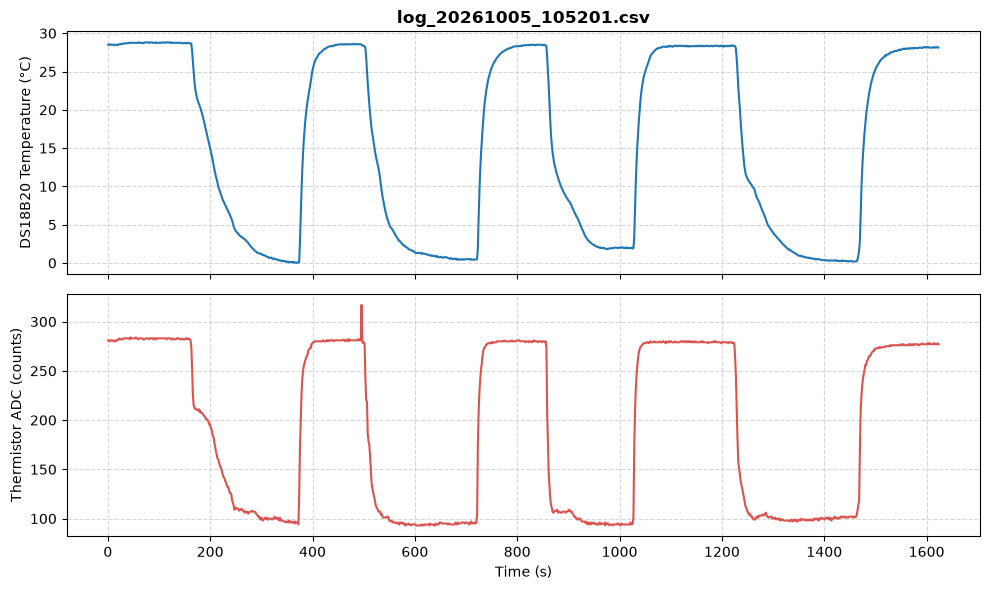

In [10]:
# Response-time log (second configuration): load and plot
response_file = "../data/log_20261005_105201.csv"

resp_df = pd.read_csv(response_file)
resp_df.columns = resp_df.columns.str.strip()
resp_t = resp_df["time_ms"] / 1000.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(resp_t, resp_df["temp_c"], color="#1f77b4", lw=1.5)
ax1.set_ylabel("DS18B20 Temperature (°C)")
ax1.set_title(os.path.basename(response_file), fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.plot(resp_t, resp_df["adc"], color="#d9534f", lw=1.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Thermistor ADC (counts)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Segmenting the response test

Removes the spike, drops the first cycle and the unfinished last piece, then labels the top, bottom and transition parts of the 3 kept periods.

In [14]:
# Response test: remove anomalies, drop the first cycle, split the rest into 3 periods
seg = resp_df.dropna(subset=["adc"]).reset_index(drop=True)
seg["t_s"] = seg["time_ms"] / 1000.0
adc = seg["adc"].astype(float)

# 1. Anomalies: a point is a spike if it sits far from the rolling median of its neighbours
dev = (adc - adc.rolling(9, center=True, min_periods=1).median()).abs()
spike = dev > max(8.0, 6 * 1.4826 * dev.median())
clean = seg[~spike].reset_index(drop=True)
a = clean["adc"].astype(float)

# 2. Find each sharp rise (ice -> room): ADC climbs > 30 % of its full span within K samples
K, MIN_RUN = 3, 2
jump = ((a.shift(-K) - a) > 0.3 * (a.max() - a.min())).fillna(False).values
starts, run = [], 0
for i, flag in enumerate(jump):
    run = run + 1 if flag else 0
    if run == MIN_RUN:
        starts.append(i - MIN_RUN + 1)

# 3. Cut at every rise: piece 0 is the first cycle, the last piece is unfinished -> keep the 3 in between
cuts = [0] + starts + [len(clean)]
pieces = [clean.iloc[s:e].copy() for s, e in zip(cuts[:-1], cuts[1:])]
periods = pieces[1:-1]

# 4. Top (room) and bottom (ice) parts of every period
SETTLE = 0.05
rows = []
for n, p in enumerate(periods, start=1):
    mid = (p["adc"].max() + p["adc"].min()) / 2
    top_lvl = p.loc[p["adc"] > mid, "adc"].median()
    bot_lvl = p.loc[p["adc"] < mid, "adc"].median()
    band = SETTLE * (top_lvl - bot_lvl)
    p["part"] = np.where(p["adc"] >= top_lvl - band, "top",
                 np.where(p["adc"] <= bot_lvl + band, "bottom", "transition"))
    p["t_rel_s"] = p["t_s"] - p["t_s"].iloc[0]
    rows.append({"Period": n, "Start (s)": p["t_s"].iloc[0], "Length (s)": p["t_rel_s"].iloc[-1],
                 "Top ADC": top_lvl, "Bottom ADC": bot_lvl,
                 "Top pts": int((p["part"] == "top").sum()), "Bottom pts": int((p["part"] == "bottom").sum())})
summary_df = pd.DataFrame(rows)
summary_df

,Period,Start (s),Length (s),Top ADC,Bottom ADC,Top pts,Bottom pts
0,1,370.869,346.192,280.0,95.0,73,124
1,2,718.566,304.021,280.0,96.0,82,80
2,3,1024.092,439.534,279.0,100.0,124,146


Prints what the segmentation found: removed points, number of pieces, and a table for each kept period.

In [15]:
# Details of the segmentation
print(f"Anomalies removed : {int(spike.sum())} point(s) at t = {seg.loc[spike, 't_s'].round(1).tolist()} s")
print(f"Pieces found      : {len(pieces)}  (first cycle and last unfinished piece dropped)")
print(f"Periods kept      : {len(periods)}\n")
print(summary_df.round(1).to_string(index=False))


Anomalies removed : 1 point(s) at t = [495.8] s
Pieces found      : 5  (first cycle and last unfinished piece dropped)
Periods kept      : 3

 Period  Start (s)  Length (s)  Top ADC  Bottom ADC  Top pts  Bottom pts
      1      370.9       346.2    280.0        95.0       73         124
      2      718.6       304.0    280.0        96.0       82          80
      3     1024.1       439.5    279.0       100.0      124         146


Plots the kept periods (top, bottom, transition) over the discarded parts to check the segmentation.

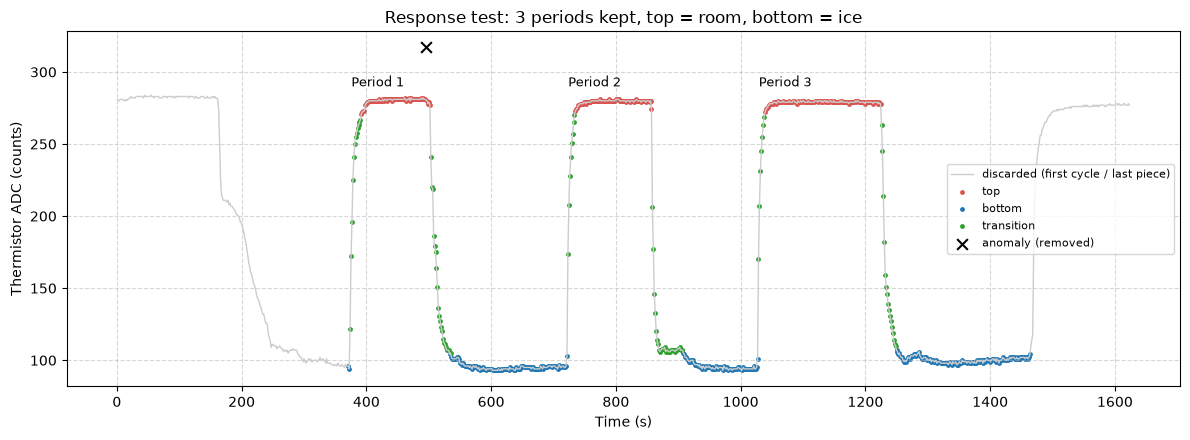

In [16]:
# Check visually: kept periods coloured, first cycle / last piece grey
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(clean["t_s"], clean["adc"], color="0.8", lw=1, label="discarded (first cycle / last piece)")
colors = {"top": "#d9534f", "bottom": "#1f77b4", "transition": "#2ca02c"}
for n, p in enumerate(periods, start=1):
    for part, c in colors.items():
        m = p["part"] == part
        ax.scatter(p.loc[m, "t_s"], p.loc[m, "adc"], s=6, color=c,
                   label=f"{part}" if n == 1 else None)
    ax.text(p["t_s"].iloc[0] + 5, clean["adc"].max() + 6, f"Period {n}", fontsize=9)
ax.scatter(seg.loc[spike, "t_s"], seg.loc[spike, "adc"], marker="x", color="black", s=60, label="anomaly (removed)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Thermistor ADC (counts)")
ax.set_title("Response test: 3 periods kept, top = room, bottom = ice")
ax.grid(True, linestyle="--", alpha=0.5); ax.legend(fontsize=8, loc="center right")
plt.tight_layout(); plt.show()


### Comparing the 3 periods

Aligns the 3 periods on their own rise and fall, and overlays them in 3 colours for the heating and cooling steps.

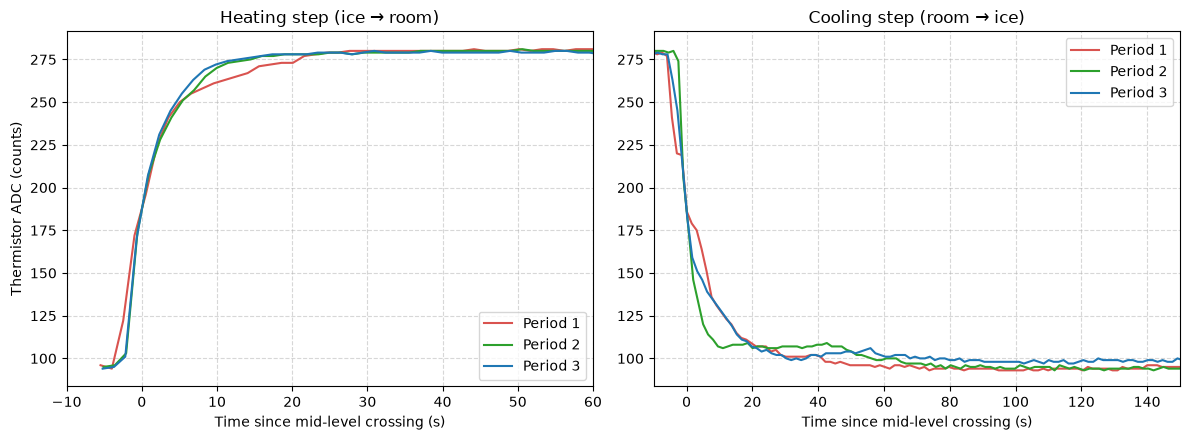

In [23]:
# Align every period on its own rise and its own fall (t = 0 where the ADC crosses its mid-level)
period_colors = ["#d9534f", "#2ca02c", "#1f77b4"]
RISE_WIN, FALL_WIN = (-10, 60), (-10, 150)                          # seconds around each crossing

def mid_cross(t, y, mid, rising):
    idx = np.flatnonzero(y >= mid) if rising else np.flatnonzero(y <= mid)
    i = idx[0]
    return t[i - 1] + (mid - y[i - 1]) * (t[i] - t[i - 1]) / (y[i] - y[i - 1]), i

for p in periods:
    t, y = p["t_s"].values, p["adc"].values.astype(float)
    mid = (y.max() + y.min()) / 2
    t_rise, i_rise = mid_cross(t, y, mid, rising=True)
    t_fall, _ = mid_cross(t[i_rise:], y[i_rise:], mid, rising=False)
    p["t_rise"], p["t_fall"] = t - t_rise, t - t_fall

fig, (ax_r, ax_f) = plt.subplots(1, 2, figsize=(12, 4.5))
for n, (p, c) in enumerate(zip(periods, period_colors), start=1):
    ax_r.plot(p["t_rise"], p["adc"], color=c, lw=1.5, label=f"Period {n}")
    ax_f.plot(p["t_fall"], p["adc"], color=c, lw=1.5, label=f"Period {n}")
ax_r.set_xlim(*RISE_WIN); ax_f.set_xlim(*FALL_WIN)
ax_r.set_title("Heating step (ice → room)"); ax_f.set_title("Cooling step (room → ice)")
for ax in (ax_r, ax_f):
    ax.set_xlabel("Time since mid-level crossing (s)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
ax_r.set_ylabel("Thermistor ADC (counts)")
plt.tight_layout()
plt.show()


Plots the mean of the 3 periods with ±1 SD as dashed lines, to show the average response and its spread.

Heating step (ice → room): mean SD = 2.0 counts, max SD = 12.2 counts at t = -2 s
Cooling step (room → ice): mean SD = 4.2 counts, max SD = 27.5 counts at t = -2 s


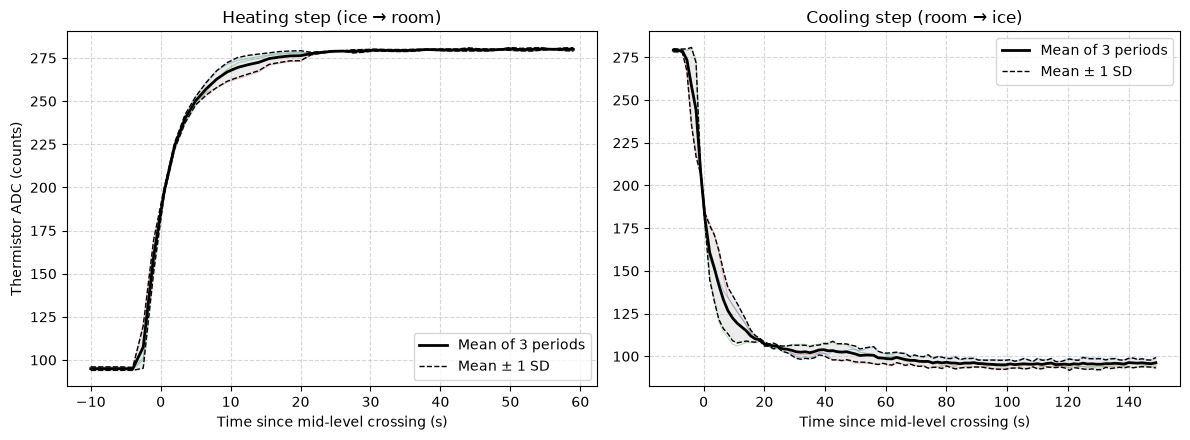

In [24]:
# Mean of the 3 periods with +/- 1 standard deviation drawn as two lines either side
def mean_sd(col, win):
    grid = np.arange(win[0], win[1], 1.5)                            # common time axis (~ sample spacing)
    stack = np.array([np.interp(grid, p[col], p["adc"]) for p in periods])
    return grid, stack, stack.mean(axis=0), stack.std(axis=0, ddof=1)   # sample SD of the 3 periods

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, win, title in [(axes[0], "t_rise", RISE_WIN, "Heating step (ice → room)"),
                            (axes[1], "t_fall", FALL_WIN, "Cooling step (room → ice)")]:
    grid, stack, mean, sd = mean_sd(col, win)
    for y, c in zip(stack, period_colors):
        ax.plot(grid, y, color=c, lw=0.8, alpha=0.35)
    ax.plot(grid, mean, color="black", lw=2, label="Mean of 3 periods")
    ax.plot(grid, mean + sd, color="black", lw=1, linestyle="--", label="Mean ± 1 SD")
    ax.plot(grid, mean - sd, color="black", lw=1, linestyle="--")
    ax.fill_between(grid, mean - sd, mean + sd, color="0.5", alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Time since mid-level crossing (s)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    print(f"{title}: mean SD = {sd.mean():.1f} counts, max SD = {sd.max():.1f} counts at t = {grid[sd.argmax()]:.0f} s")
axes[0].set_ylabel("Thermistor ADC (counts)")
plt.tight_layout()
plt.show()


### Response time: pooled first-order fit

Defines the cubic and β-model calibrations (ADC to °C) and the delayed first-order (Newton's law) model.

In [32]:
# Calibrations from earlier in this notebook: cubic polynomial and NTC beta-model (ADC -> deg C)
def adc_to_T_cubic(adc):
    adc = np.asarray(adc, float)
    return c3 * adc**3 + c2 * adc**2 + c1 * adc + c0

def adc_to_T_beta(adc):
    adc = np.asarray(adc, float)
    return 1.0 / (slope_cal * np.log((1023 - adc) / adc) + intercept_cal) - 273.15

calibrations = {"Cubic": adc_to_T_cubic, "β-model": adc_to_T_beta}

# Delayed first-order step (Newton's law): flat until t0, then exponential approach to T_f
def first_order(t, T_i, T_f, tau, t0):
    return np.where(t < t0, T_i, T_f + (T_i - T_f) * np.exp(-(t - t0) / tau))

# Time window around the mid-level crossing used for each step
steps = {"Heating": ("t_rise", RISE_WIN), "Cooling": ("t_fall", FALL_WIN)}


Fits one model to all 3 periods at once (shared τ, start and end temperature, own delay per period) and gets the error by leaving one period out.

In [33]:
from scipy.optimize import least_squares

def pooled_fit(ts, Ts):
    """One delayed first-order model for all periods: shared T_start, T_end, tau; own delay t0 per period."""
    n = len(ts)
    T_i0 = np.mean([np.median(T[:5]) for T in Ts])
    T_f0 = np.mean([np.median(T[-10:]) for T in Ts])
    def resid(q):
        T_i, T_f, tau, t0s = q[0], q[1], q[2], q[3:]
        return np.concatenate([T - first_order(t, T_i, T_f, tau, t0) for t, T, t0 in zip(ts, Ts, t0s)])
    q0 = [T_i0, T_f0, 5.0] + [-3.0] * n
    lo = [min(T_i0, T_f0) - 3, min(T_i0, T_f0) - 3, 0.1] + [-8.0] * n
    hi = [max(T_i0, T_f0) + 3, max(T_i0, T_f0) + 3, 80.0] + [5.0] * n
    sol = least_squares(resid, q0, bounds=(lo, hi))
    return sol.x, np.sqrt(np.mean(sol.fun ** 2))

pooled, pooled_rows = {}, []
for direction, (col, win) in steps.items():
    for cal_name, cal in calibrations.items():
        ts, Ts = [], []
        for p in periods:
            m = ((p[col] >= win[0]) & (p[col] <= win[1])).values
            ts.append(p.loc[m, col].values)
            Ts.append(cal(p.loc[m, "adc"].values))
        q, rmse = pooled_fit(ts, Ts)

        # Uncertainty: leave one period out (jackknife) -> only 3 periods, so this is the honest error
        loo = [pooled_fit([t for j, t in enumerate(ts) if j != k], [T for j, T in enumerate(Ts) if j != k])[0][2]
               for k in range(len(ts))]
        tau_se = np.sqrt((len(loo) - 1) / len(loo) * np.sum((np.array(loo) - np.mean(loo)) ** 2))

        pooled[(direction, cal_name)] = dict(q=q, ts=ts, Ts=Ts, rmse=rmse)
        pooled_rows.append({"Step": direction, "Calibration": cal_name, "tau (s)": q[2], "tau jackknife se (s)": tau_se,
                            "10-90% (s)": 2.197 * q[2], "T start (°C)": q[0], "T end (°C)": q[1],
                            "delays t0 (s)": ", ".join(f"{x:.1f}" for x in q[3:]), "RMSE (°C)": rmse})
pooled_df = pd.DataFrame(pooled_rows)


Prints the pooled fit results: τ with its leave-one-out error, 10–90 % time, start and end temperature, and RMSE.

In [34]:
# Pooled fit results (all 3 periods fitted at once)
print(pooled_df.round(2).to_string(index=False))


   Step Calibration  tau (s)  tau jackknife se (s)  10-90% (s)  T start (°C)  T end (°C)    delays t0 (s)  RMSE (°C)
Heating       Cubic     3.54                  0.32        7.78          0.63       26.55 -3.0, -2.5, -2.6       0.47
Heating     β-model     3.32                  0.32        7.29          0.18       26.93 -3.1, -2.5, -2.6       0.50
Cooling       Cubic     7.66                  2.17       16.83         26.00        1.09 -4.0, -4.3, -4.1       0.92
Cooling     β-model     8.61                  2.20       18.91         26.43        0.72 -4.0, -4.6, -4.2       1.02


Plots the single pooled curve over the data of all 3 periods, with residuals below.

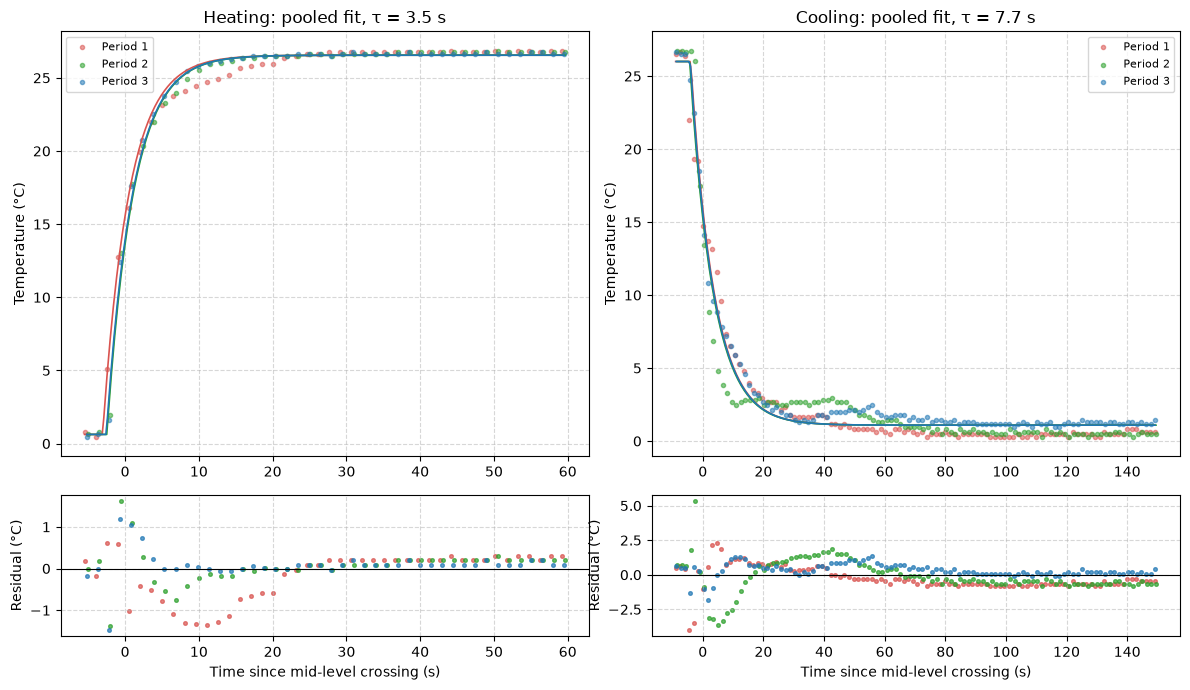

In [35]:
# Pooled fit (cubic calibration): all 3 periods with the single shared curve, residuals below
fig, axes = plt.subplots(2, 2, figsize=(12, 7), gridspec_kw={"height_ratios": [3, 1]})
for c, direction in enumerate(steps):
    d = pooled[(direction, "Cubic")]
    q = d["q"]
    ax, axr = axes[0, c], axes[1, c]
    for k, (t, T, col) in enumerate(zip(d["ts"], d["Ts"], period_colors)):
        tt = np.linspace(t.min(), t.max(), 300)
        ax.scatter(t, T, s=9, color=col, alpha=0.55, label=f"Period {k + 1}")
        ax.plot(tt, first_order(tt, q[0], q[1], q[2], q[3 + k]), color=col, lw=1.2)
        axr.scatter(t, T - first_order(t, q[0], q[1], q[2], q[3 + k]), s=7, color=col, alpha=0.7)
    ax.set_title(f"{direction}: pooled fit, τ = {q[2]:.1f} s")
    ax.set_ylabel("Temperature (°C)"); ax.grid(True, linestyle="--", alpha=0.5); ax.legend(fontsize=8)
    axr.axhline(0, color="black", lw=0.8)
    axr.set_xlabel("Time since mid-level crossing (s)"); axr.set_ylabel("Residual (°C)")
    axr.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
